In [16]:
# in the name of God the most compassionate the most merciful 
# in this section Im going to review using rnns(rnn/gru/lstm)
# and use it to prediction/regression, generate text, classification, sentiment analysis
# we use pytorch
import numpy as np 
import torch
import torch.nn as nn
import matplotlib.pyplot as plt 
%matplotlib inline 
plt.rcParams["figure.figsize"] = (4,3)
print(f'torch version: {torch.__version__}')

torch version: 2.1.0+cu121


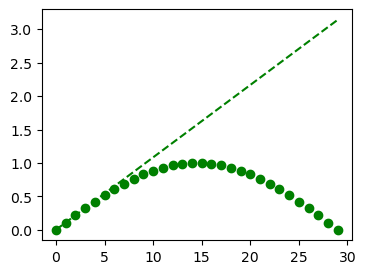

In [17]:
# lets first get familiar with the rnn. 
# to start, lets create some dummy numbers, we use linspace to create
# evenly spaced numbers betwene two points. here we are going for 30
# numbers.
#  
xs = torch.linspace(0, torch.pi, 30)
xs_sin = torch.sin(xs)
# lets plot this and see what we are dealing here 
# plt.figure(figsize=(4,3))
plt.plot(xs, color='green', linestyle='--', label='raw')
plt.plot(xs_sin, 'go', label='sin')

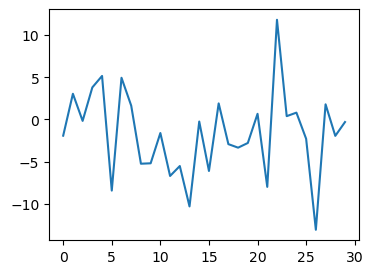

In [51]:
# we did this to create somekind of underlying structure for the model to discover. 
# we could use a formula with random numbers to create that, like a regression problem
# plt.figure(figsize=(4,3))
XS = torch.randn(size=(30,))
XS.mul_(5).add_(-3)
plt.plot(XS)

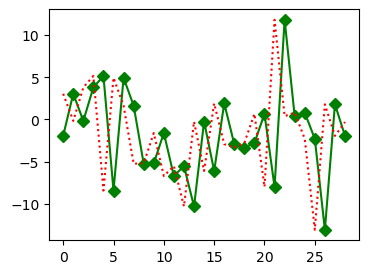

In [63]:
# ok that was the sample for our timeseries prediction example, whats the label? 
# the label is usually the next token/item in the sequence 
xs = XS[:-1]
ys = XS[1:]
# we can use different linestyles such as 'solid', 'dashed','dotted' or 'None'
# or their shortcuts in fmt parameter, where we can specify the basic formattings
# like color, marker, linestyle using their shortcuts. for example  
# '-' or 'solid' : solid line
# '--' or 'dashed': Dashed line
# '-.' or 'dashdot': Dash-dot line
# ':' or 'dotted': Dotted line
# '' , ' ' or 'None': No line'
#--------------
# shortcut for markers
# '.': Point marker
# ',': Pixel marker
# 'o': Circle marker
# 'v': Triangle down marker
# '^': Triangle up marker
# '<': Triangle left marker
# '>': Triangle right marker
# '1': Tri down marker
# '2': Tri up marker
# '3': Tri left marker
# '4': Tri right marker
# 's': Square marker
# 'p': Pentagon marker
# '*': Star marker
# 'h': Hexagon1 marker
# 'H': Hexagon2 marker
# '+': Plus marker
# 'x': X marker
# 'D': Diamond marker
# 'd': Thin diamond marker
# '|': Vline marker
# '_': Hline marker
# g stands for green, r stands for red
plt.plot(xs,'g-D',label='data')
plt.plot(ys, 'r:', label='label')

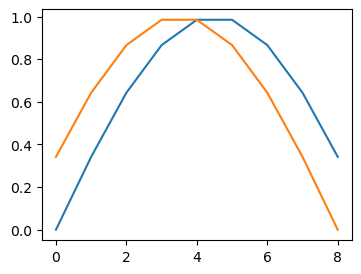

In [65]:
# now lets create a dataset of these points. we need much more points for training our network
# one way is to create a dataset completely, or use generators to generate data on the fly 
# since we intend on using sin, we can easily do this by creating x numbers from a given i 
def generate_data_label(i, sequence_length=10):
    x = torch.linspace(i*torch.pi, i+1*torch.pi, sequence_length).sin()
    data = x[:-1]
    label = x[1:]
    yield data, label

# note a generator is already an iterator, so you don’t need to call iter() on it 
# (if it was an iterable like a list, tuple, then you had to use iter to make it iterator)
# but since a generator is already an iterator the next suffices
x,y = next(generate_data_label(0))
# newer version of pytorch offer many convinient functions such as tolist use them for small arrays
# for larger ones, use numpy to avoid needless overhead/copying
plt.plot(x.tolist())
plt.plot(y.tolist())

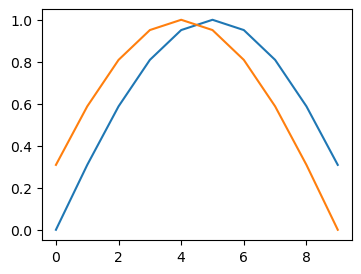

In [71]:
# but wait a second this is not right! we want a sequence of x timestep, this is one long 1d array! we want (batch,timestep,feature)
# lets fix this 
def generate_data_label(i, sequence_length=10):
    x = torch.linspace(i*torch.pi, i+1*torch.pi, sequence_length+1).sin()
    data = x[:-1].view(1,sequence_length,1)
    label = x[1:].view(1,sequence_length,1)
    yield data, label 
x,y = next(generate_data_label(0))
plt.plot(x.numpy().reshape(-1))
plt.plot(y.numpy().reshape(-1))    

In [72]:
# now lets create our RNN model 
class RNN_predictor(nn.Module):
    def __init__(self, input_size, output_size, hidden_size, num_layers=1, dropout=0.5, is_bidirectional=False) -> None:
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout
        self.is_bidirectional = is_bidirectional
        # lets create a rnn layer 
        self.rnn = nn.RNN()